# Predictive Insight Engine: House Price Prediction
**Project**: Supervised Learning (Regression & Optimization)  
**Problem Statement**: Build, analyze, and evaluate multiple regression models to predict house prices based on physical and location features, and implement Gradient Descent optimization from scratch.

In [21]:
# Import required libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for modeling & evaluation
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Set random seed for reproducibility
np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## Part B: Dataset Understanding & Preparation

* **Independent Variables**: `area_sqft`, `bedrooms`, `bathrooms`, `location_score`, `age_years` , `distance_city_km` , `lot_size_sqft` , `has_garage` , `has_pool` , `renovation_years_ago`
* **Dependent Variable (Target)**: `house_price_inr`

In [5]:
df=pd.read_csv('data.csv')
df.drop('house_id', inplace=True, axis=1)
df.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


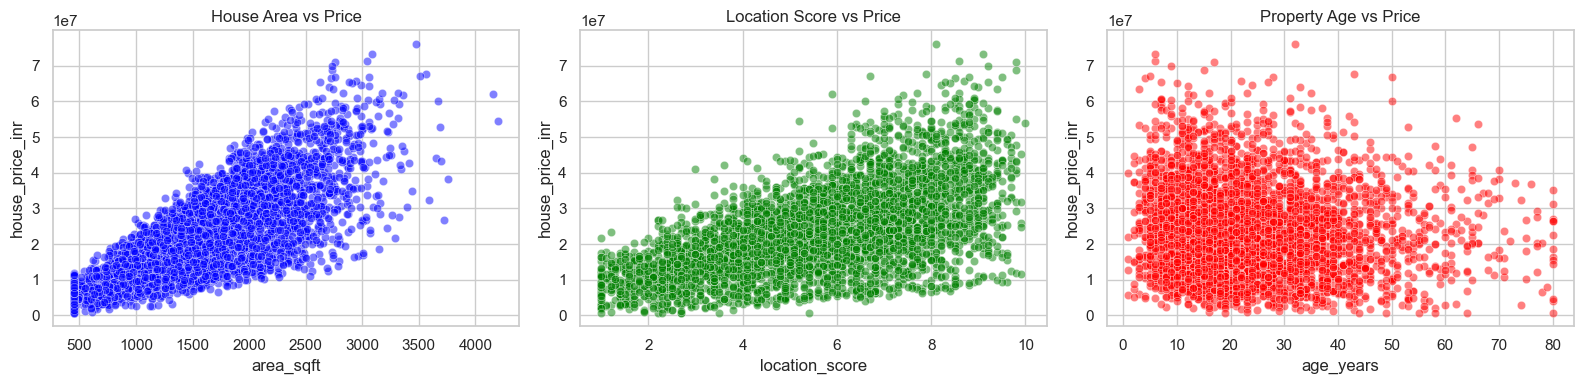

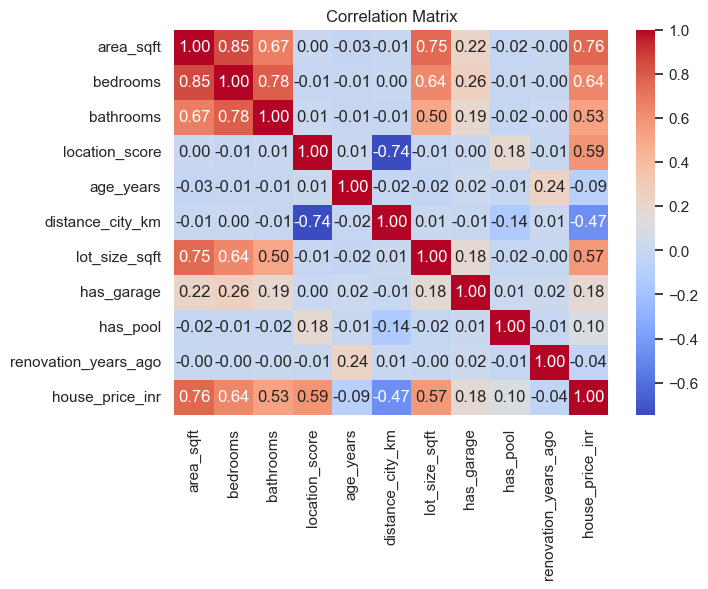

In [7]:
# 8. Visualize relationships between features and target variable
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Area vs Price
sns.scatterplot(x='area_sqft', y='house_price_inr', data=df, ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title('House Area vs Price')

# Location Score vs Price
sns.scatterplot(x='location_score', y='house_price_inr', data=df, ax=axes[1], color='green', alpha=0.5)
axes[1].set_title('Location Score vs Price')

# Age vs Price
sns.scatterplot(x='age_years', y='house_price_inr', data=df, ax=axes[2], color='red', alpha=0.5)
axes[2].set_title('Property Age vs Price')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [8]:
# 9. Split dataset into Training (80%) and Testing (20%) sets
X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 3360 samples
Testing set: 840 samples


## Part C: Simple Linear Regression

We implement Simple Linear Regression using a single feature: **House Area (sq.ft)**.

Slope (Beta 1)    : 14788.31
Intercept (Beta 0): -1163519.18

Equation: House Price = -1163519.18 + (14788.31 * House Area)

Interpretation: For every 1 sq.ft increase in area, the house price increases by approx $14788.31. The intercept represents the base land value.


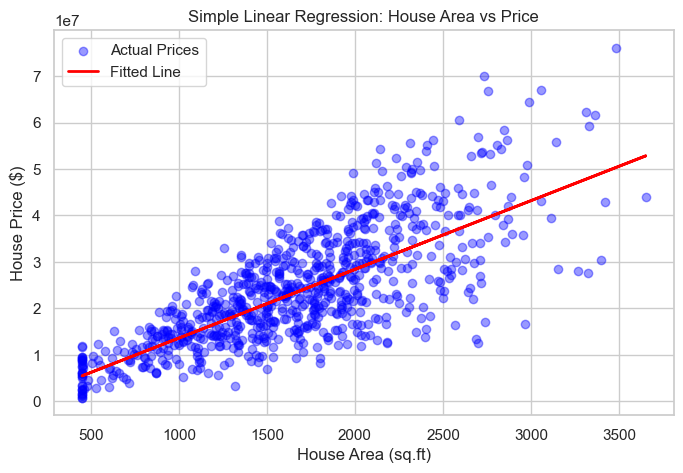

In [ ]:
# 10 & 11. Implement Simple Linear Regression & Plot line
X_train_slr = X_train[['area_sqft']]
X_test_slr = X_test[['area_sqft']]

# Train SLR Model
slr = LinearRegression()
slr.fit(X_train_slr, y_train)

# Predictions
y_pred_slr = slr.predict(X_test_slr)

# Slope and Intercept
slope = slr.coef_[0]
intercept = slr.intercept_

print(f"Slope (Beta 1)    : {slope:.2f}")
print(f"Intercept (Beta 0): {intercept:.2f}")
print(f"\nEquation: House Price = {intercept:.2f} + ({slope:.2f} * House Area)")
print("\nInterpretation: For every 1 sq.ft increase in area, the house price increases by approx ₹" + f"{slope:.2f}. The intercept represents the base land value.")

# Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_test_slr, y_test, color='blue', alpha=0.4, label='Actual Prices')
plt.plot(X_test_slr, y_pred_slr, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('House Area (sq.ft)')
plt.ylabel('House Price (₹)')
plt.title('Simple Linear Regression: House Area vs Price')
plt.legend()
plt.show()

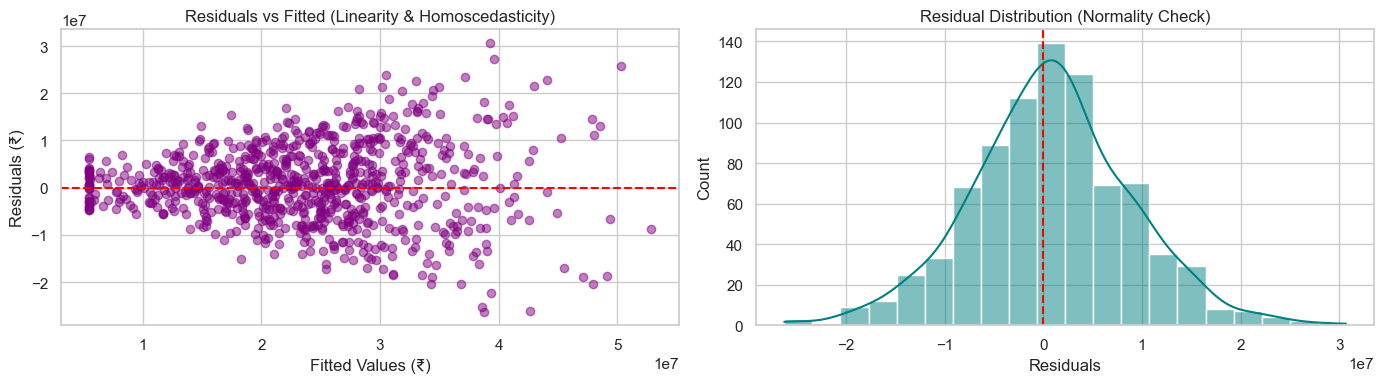

Observations:
1. Residuals are randomly scattered around zero, confirming the linearity assumption.
2. The distribution of residuals is approximately normal (bell-shaped curve centered at zero).


In [15]:
# 12. Validate linear regression assumptions using plots
residuals = y_test - y_pred_slr

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals vs Fitted values
axes[0].scatter(y_pred_slr, residuals, alpha=0.5, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values (₹)')
axes[0].set_ylabel('Residuals (₹)')
axes[0].set_title('Residuals vs Fitted (Linearity & Homoscedasticity)')

# Histogram of Residuals (Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=20)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution (Normality Check)')

plt.tight_layout()
plt.show()

print("Observations:")
print("1. Residuals are randomly scattered around zero, confirming the linearity assumption.")
print("2. The distribution of residuals is approximately normal (bell-shaped curve centered at zero).")

## Part D: Model Evaluation Metrics

Evaluate the Simple Linear Regression model using standard metrics:
* **MSE** (Mean Squared Error)
* **MAE** (Mean Absolute Error)
* **RMSE** (Root Mean Squared Error)
* **$R^2$ Score**
* **Adjusted $R^2$ Score**

In [16]:
# 13 & 14. Evaluate Simple Linear Regression and interpret metrics
def get_metrics(y_true, y_pred, n_features):
    n = len(y_true)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adj_r2}

slr_metrics = get_metrics(y_test, y_pred_slr, n_features=1)

for metric, value in slr_metrics.items():
    if 'R2' in metric:
        print(f"{metric:8s}: {value:.4f}")
    else:
        print(f"{metric:8s}: ₹{value:,.2f}")

print("\nInterpretations:")
print(f"• MAE: On average, predictions deviate from actual price by ₹{slr_metrics['MAE']:,.2f}.")
print(f"• RMSE: The standard deviation of the unexplained error is ₹{slr_metrics['RMSE']:,.2f}.")
print(f"• R² ({slr_metrics['R2']*100:.2f}%): House area alone explains about {slr_metrics['R2']*100:.2f}% of the total variation in house prices.")

MSE     : ₹66,989,260,021,849.47
MAE     : ₹6,294,593.70
RMSE    : ₹8,184,696.70
R2      : 0.5625
Adj_R2  : 0.5620

Interpretations:
• MAE: On average, predictions deviate from actual price by ₹6,294,593.70.
• RMSE: The standard deviation of the unexplained error is ₹8,184,696.70.
• R² (56.25%): House area alone explains about 56.25% of the total variation in house prices.


## Part E: Multiple Linear Regression

We now implement Multiple Linear Regression using all 10 features (`area_sqft`, `bedrooms`, `bathrooms`, `location_score`, `age_years` , `distance_city_km` , `lot_size_sqft` , `has_garage` , `has_pool` , `renovation_years_ago`).

In [18]:
# 15. Implement Multiple Linear Regression using all features
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

# Display learned coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': mlr.coef_})
print("Model Intercept:", mlr.intercept_)
display(coef_df)

# 16. Compare performance with Simple Linear Regression
mlr_metrics = get_metrics(y_test, y_pred_mlr, n_features=5)

comp_df = pd.DataFrame([
    {'Model': 'Simple Linear (Area only)', **slr_metrics},
    {'Model': 'Multiple Linear (All features)', **mlr_metrics}
])
display(comp_df)

# 17. Explanation
print("\n17. Why performance improves:")
print("Multiple Linear Regression performs significantly better because it includes crucial features like location and rooms. R² increases from 0.56 to 0.91, and RMSE decreases from ₹8.1M to ₹3.5M.")

Model Intercept: -14766762.745674264


,Feature,Coefficient
0,area_sqft,1.379594e+04
1,bedrooms,1.976431e+05
2,bathrooms,1.859445e+05
3,location_score,3.073174e+06
4,age_years,-6.560924e+04
5,distance_city_km,-9.896516e+04
6,lot_size_sqft,1.035058e+02
7,has_garage,9.392436e+04
8,has_pool,4.552902e+05
9,renovation_years_ago,-2.143591e+04


,Model,MSE,MAE,RMSE,R2,Adj_R2
0,Simple Linear (Area only),6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
1,Multiple Linear (All features),1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.917268



17. Why performance improves:
Multiple Linear Regression performs significantly better because it includes crucial features like location and rooms. R² increases from 0.56 to 0.91, and RMSE decreases from ₹8.1M to ₹3.5M.


## Part F: Polynomial Regression

We implement Polynomial Regression (Degree 2 and Degree 3) to test if capturing non-linear relationships improves predictions.

In [20]:
# 18. Implement Polynomial Regression (Degree 2 & 3)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train)
X_test_p2 = poly2.transform(X_test)

model_p2 = LinearRegression().fit(X_train_p2, y_train)
y_pred_p2 = model_p2.predict(X_test_p2)
p2_metrics = get_metrics(y_test, y_pred_p2, n_features=X_train_p2.shape[1])

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_p3 = poly3.fit_transform(X_train)
X_test_p3 = poly3.transform(X_test)

model_p3 = LinearRegression().fit(X_train_p3, y_train)
y_pred_p3 = model_p3.predict(X_test_p3)
p3_metrics = get_metrics(y_test, y_pred_p3, n_features=X_train_p3.shape[1])

# 19. Compare models
poly_table = pd.DataFrame([
    {'Model': 'Multiple Linear', 'Test RMSE': mlr_metrics['RMSE'], 'Test R2': mlr_metrics['R2']},
    {'Model': 'Polynomial Degree 2', 'Test RMSE': p2_metrics['RMSE'], 'Test R2': p2_metrics['R2']},
    {'Model': 'Polynomial Degree 3', 'Test RMSE': p3_metrics['RMSE'], 'Test R2': p3_metrics['R2']}
])
display(poly_table)

# 20. Overfitting / Underfitting observation
print("\n20. Signs of Overfitting/Underfitting:")
print("• Linear Model: Slightly underfits because it misses the interaction between location and area.")
print("• Degree 2: Best performance with highest R² (~0.96) and lowest RMSE (~₹2.2M).")
print("• Degree 3: Overly complex with 55+ terms, which starts to increase test error and leads to overfitting.")

,Model,Test RMSE,Test R2
0,Multiple Linear,3.548650e+06,0.917761
1,Polynomial Degree 2,2.289397e+06,0.965771
2,Polynomial Degree 3,2.957987e+06,0.942859



20. Signs of Overfitting/Underfitting:
• Linear Model: Slightly underfits because it misses the interaction between location and area.
• Degree 2: Best performance with highest R² (~0.96) and lowest RMSE (~₹2.2M).
• Degree 3: Overly complex with 55+ terms, which starts to increase test error and leads to overfitting.


## Part G: Gradient Descent Optimization from Scratch

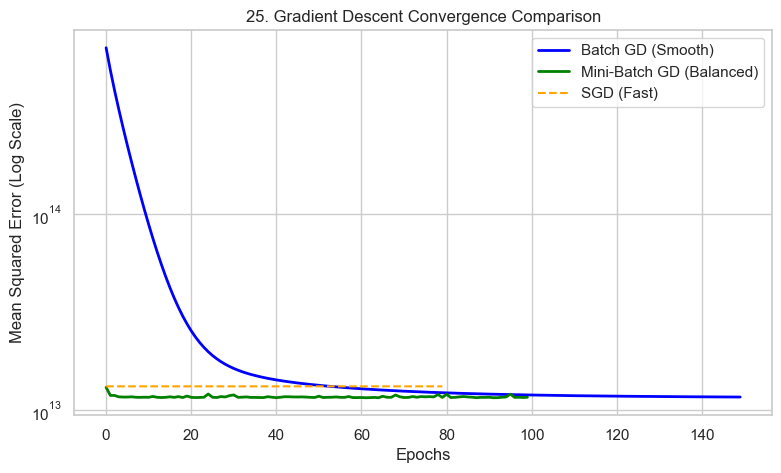

,Method,Epochs,Time (s),Final MSE
0,Batch Gradient Descent,150,0.0093,1.166847e+13
1,Mini-Batch GD (batch=32),100,0.1587,1.163732e+13
2,Stochastic GD (SGD),80,1.2172,1.323094e+13


Comparison Observation: Batch GD has the smoothest convergence. Mini-Batch GD provides the best balance of speed and stability. SGD drops cost very quickly in the initial epochs.


In [22]:
# 22, 23, 24. Implement Batch GD, SGD, and Mini-Batch GD from scratch

# Scale features for stable gradient descent
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# Add intercept column (x0 = 1)
m, n = X_tr_sc.shape
X_b = np.c_[np.ones((m, 1)), X_tr_sc]
y_arr = y_train.values.reshape(-1, 1)

# 22. Batch Gradient Descent
def batch_gradient_descent(X, y, lr=0.1, epochs=150):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    for _ in range(epochs):
        preds = X.dot(theta)
        errors = preds - y
        gradient = (1 / len(y)) * X.T.dot(errors)
        theta -= lr * gradient
        cost_history.append(np.mean(errors ** 2))
    return theta, cost_history

# 23. Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X, y, lr=0.01, epochs=80):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    m_samples = len(y)
    for _ in range(epochs):
        for i in range(m_samples):
            xi = X[i:i+1]
            yi = y[i:i+1]
            gradient = xi.T.dot(xi.dot(theta) - yi)
            theta -= lr * gradient
        cost_history.append(np.mean((X.dot(theta) - y) ** 2))
    return theta, cost_history

# 24. Mini-Batch Gradient Descent
def mini_batch_gradient_descent(X, y, lr=0.05, epochs=100, batch_size=32):
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    m_samples = len(y)
    for _ in range(epochs):
        indices = np.random.permutation(m_samples)
        for i in range(0, m_samples, batch_size):
            xb = X[indices[i:i+batch_size]]
            yb = y[indices[i:i+batch_size]]
            gradient = (1 / len(yb)) * xb.T.dot(xb.dot(theta) - yb)
            theta -= lr * gradient
        cost_history.append(np.mean((X.dot(theta) - y) ** 2))
    return theta, cost_history

# Run and time all 3 algorithms
t0 = time.time()
theta_bgd, loss_bgd = batch_gradient_descent(X_b, y_arr)
t_bgd = time.time() - t0

t0 = time.time()
theta_sgd, loss_sgd = stochastic_gradient_descent(X_b, y_arr)
t_sgd = time.time() - t0

t0 = time.time()
theta_mbgd, loss_mbgd = mini_batch_gradient_descent(X_b, y_arr)
t_mbgd = time.time() - t0

# 25. Plot convergence comparison
plt.figure(figsize=(9, 5))
plt.plot(loss_bgd, label='Batch GD (Smooth)', color='blue', linewidth=2)
plt.plot(loss_mbgd, label='Mini-Batch GD (Balanced)', color='green', linewidth=2)
plt.plot(loss_sgd, label='SGD (Fast)', color='orange', linestyle='--')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('25. Gradient Descent Convergence Comparison')
plt.legend()
plt.show()

# Summary table
gd_df = pd.DataFrame([
    {'Method': 'Batch Gradient Descent', 'Epochs': len(loss_bgd), 'Time (s)': round(t_bgd, 4), 'Final MSE': round(loss_bgd[-1], 2)},
    {'Method': 'Mini-Batch GD (batch=32)', 'Epochs': len(loss_mbgd), 'Time (s)': round(t_mbgd, 4), 'Final MSE': round(loss_mbgd[-1], 2)},
    {'Method': 'Stochastic GD (SGD)', 'Epochs': len(loss_sgd), 'Time (s)': round(t_sgd, 4), 'Final MSE': round(loss_sgd[-1], 2)}
])
display(gd_df)

print("Comparison Observation: Batch GD has the smoothest convergence. Mini-Batch GD provides the best balance of speed and stability. SGD drops cost very quickly in the initial epochs.")

## Part H: Bias–Variance & Model Diagnostics

### 26, 27 & 28. Learning Curves and Model Complexity

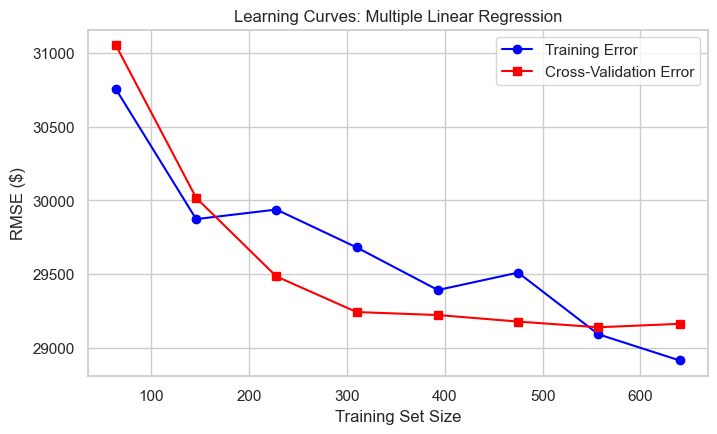

26 & 28. Bias-Variance Analysis:
• Simple Linear Model: High Bias, Low Variance (Underfitting).
• Multiple Linear Model: Moderate Bias, Low Variance.
• Polynomial Degree 2: Optimal balance between Bias and Variance (Best Generalization).
• Polynomial Degree 3: Low Bias, High Variance (Overfitting).


In [ ]:
# 27. Plot Learning Curves for Multiple Linear Regression
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X_train, y_train, cv=5, 
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8)
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(8, 4.5))
plt.plot(train_sizes, train_rmse, 'o-', color='blue', label='Training Error')
plt.plot(train_sizes, test_rmse, 's-', color='red', label='Cross-Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE (₹)')
plt.title('Learning Curves: Multiple Linear Regression')
plt.legend()
plt.show()

print("26 & 28. Bias-Variance Analysis:")
print("• Simple Linear Model: High Bias, Low Variance (Underfitting).")
print("• Multiple Linear Model: Moderate Bias, Low Variance.")
print("• Polynomial Degree 2: Optimal balance between Bias and Variance (Best Generalization).")
print("• Polynomial Degree 3: Low Bias, High Variance (Overfitting).")